In [2]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: matplotlib in c:\users\vedant mhatre\appdata\local\programs\python\python312\lib\site-packages (3.9.0)




[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = {
    "Day": [1,2,3,4,5,6,7,8,9,10],
    "Ad_Spend_USD": [200,500,150,300,450,100,250,600,350,400],
    "Items_Sold": [45,120,30,60,95,25,50,140,70,85],
    "Revenue_USD": [4500,12000,3000,6100,9200,2500,5200,14500,7100,8800],
    "Customer_Satisfaction": [65,88,45,70,92,30,75,82,80,60],
    "Department": [
        "Electronics","Electronics","Clothing",
        "Clothing","Electronics","Home",
        "Home","Electronics","Clothing","Home"
    ]
}
df_bazaar = pd.DataFrame(data)

In [13]:
sns.set_theme(style="white")

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#E0E0E0"
plt.rcParams["axes.linewidth"] = 0.8

primary_blue = "#1F4E79"
accent_orange = "#D95F02"

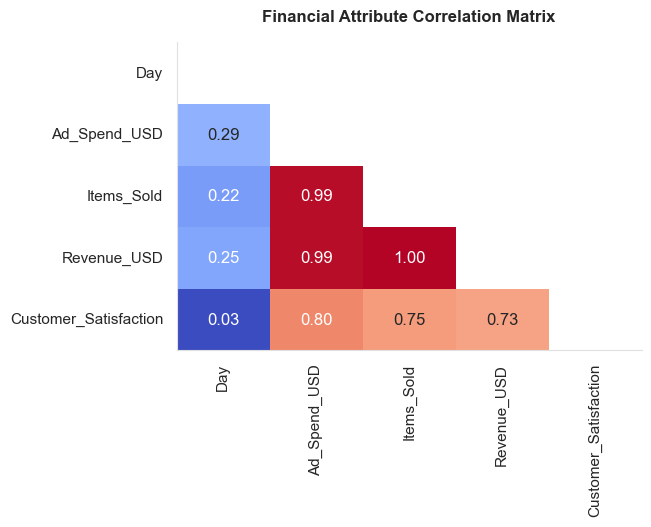

In [14]:
# Q4. Calculate Correlation Matrix

corr_matrix = df_bazaar.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(6,4))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    data=corr_matrix,
    annot=True,
    cmap="coolwarm",
    mask=mask,
    fmt=".2f",
    cbar=False
)
plt.title(
    "Financial Attribute Correlation Matrix",
    fontweight="bold",
    pad=15
)
sns.despine()
plt.show()

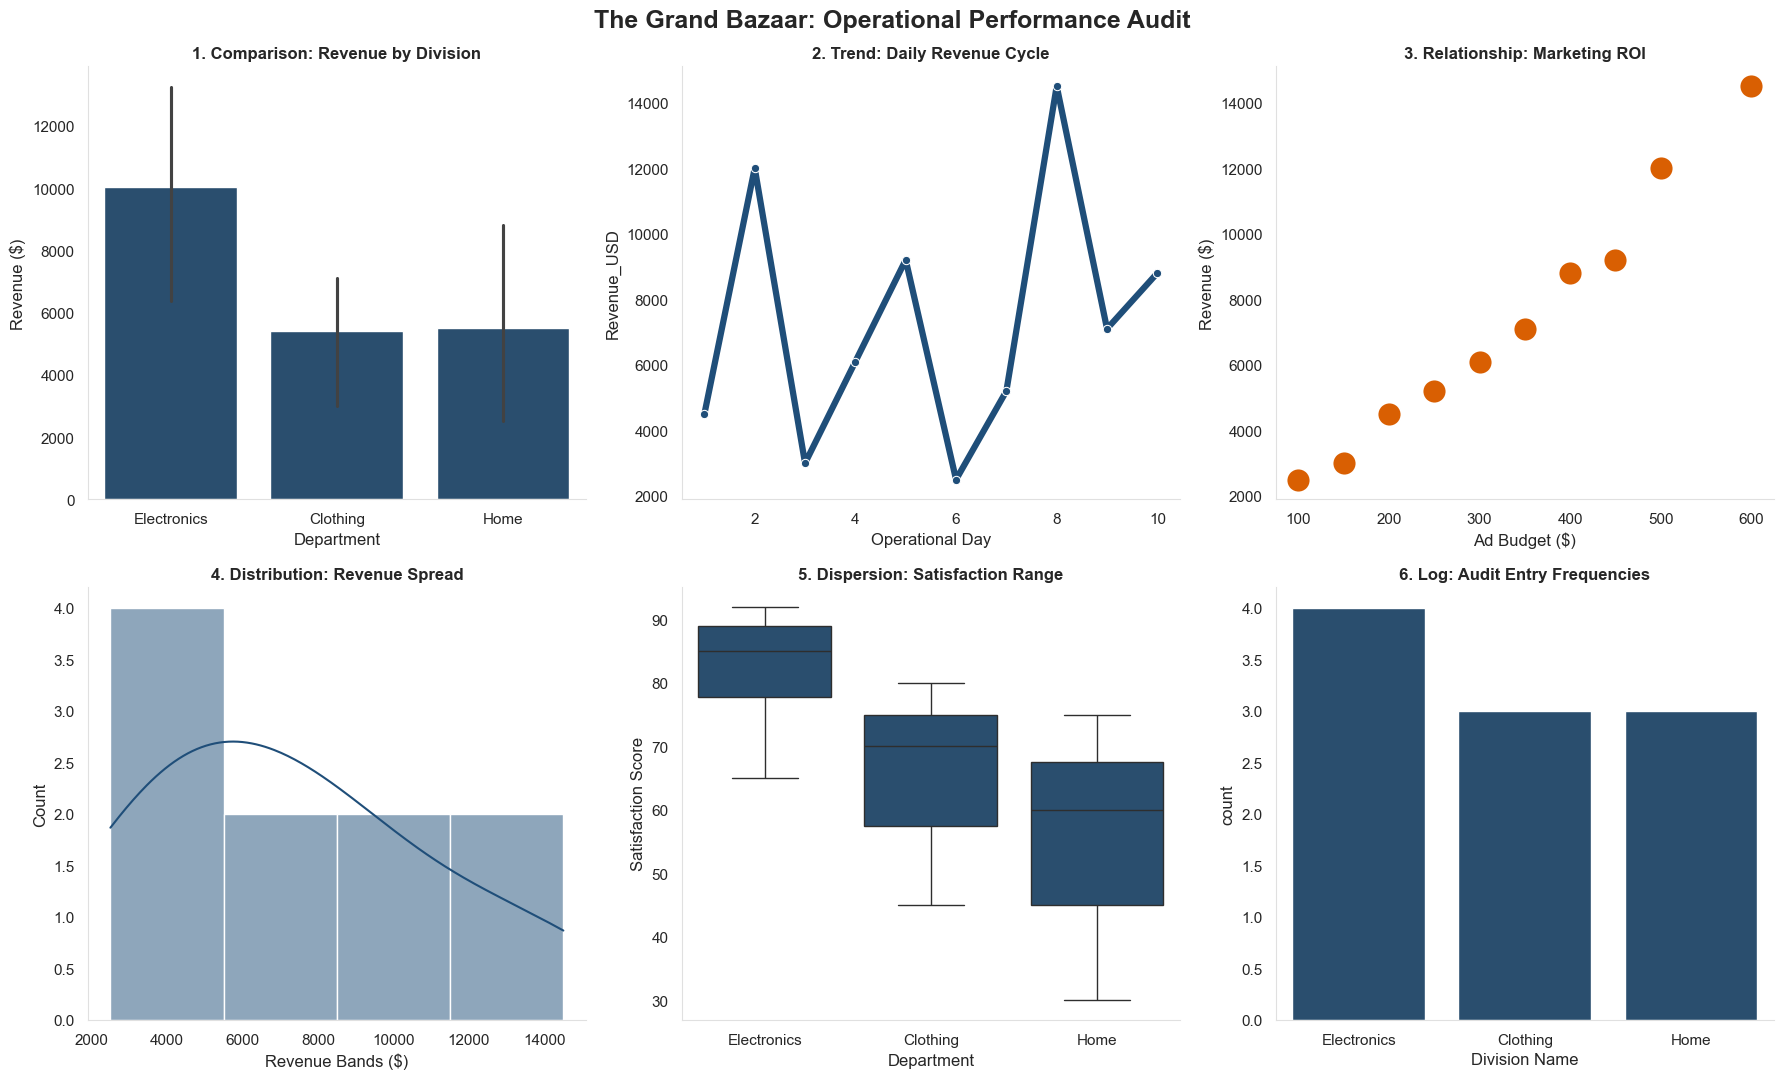

In [15]:
# Create a 2x3 grid canvas for our subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 11))
fig.suptitle("The Grand Bazaar: Operational Performance Audit", fontsize=18, fontweight="bold")

# 1. BAR CHART (Comparison Analysis)
sns.barplot(data=df_bazaar, x="Department", y="Revenue_USD", ax=axes[0, 0], color=primary_blue)
axes[0, 0].set_title("1. Comparison: Revenue by Division", fontweight="bold")
axes[0, 0].set_ylabel("Revenue ($)")

# 2. LINE CHART (Trend Over Time Analysis)
sns.lineplot(data=df_bazaar, x="Day", y="Revenue_USD", ax=axes[0, 1], color=primary_blue, marker="o", linewidth=4.5)
axes[0, 1].set_title("2. Trend: Daily Revenue Cycle", fontweight="bold")
axes[0, 1].set_xlabel("Operational Day")

# 3. SCATTER PLOT (Relationship Verification)
sns.scatterplot(data=df_bazaar, x="Ad_Spend_USD", y="Revenue_USD", ax=axes[0, 2], color=accent_orange, s=300)
axes[0, 2].set_title("3. Relationship: Marketing ROI", fontweight="bold")
axes[0, 2].set_xlabel("Ad Budget ($)")
axes[0, 2].set_ylabel("Revenue ($)")

# 4. HISTOGRAM (Univariate Distribution Shape)
sns.histplot(data=df_bazaar, x="Revenue_USD", ax=axes[1, 0], color=primary_blue, bins=4, kde=True)
axes[1, 0].set_title("4. Distribution: Revenue Spread", fontweight="bold")
axes[1, 0].set_xlabel("Revenue Bands ($)")

# 5. BOX PLOT (Dispersion & Variance)
sns.boxplot(data=df_bazaar, x="Department", y="Customer_Satisfaction", ax=axes[1, 1], color=primary_blue)
axes[1, 1].set_title("5. Dispersion: Satisfaction Range", fontweight="bold")
axes[1, 1].set_ylabel("Satisfaction Score")

# 6. COUNT PLOT (Categorical Balance)
sns.countplot(data=df_bazaar, x="Department", ax=axes[1, 2], color=primary_blue)
axes[1, 2].set_title("6. Log: Audit Entry Frequencies", fontweight="bold")
axes[1, 2].set_xlabel("Division Name")

# Optimize spacing and strip unnecessary border ink globally
sns.despine()
plt.tight_layout()
plt.show()